In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga de csvs para exploración

df_universo  = pd.read_csv('data/universo.csv')

In [63]:
df_base_clientes  = pd.read_csv('data/base_clientes.csv')
df_base_saldos_cuentas  = pd.read_csv('data/base_saldos_cuentas.csv')

In [64]:
df_universo.head()

,ID,target,periodo
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5


In [65]:
df_universo.shape

(535943, 3)

In [66]:
df_universo['target'].value_counts()

target
0    464075
1     47171
5      8489
4      6893
2      5929
3      3386
Name: count, dtype: int64

In [67]:
df_universo['target'].value_counts(normalize=True).sort_index() * 100

target
0    86.590365
1     8.801496
2     1.106274
3     0.631784
4     1.286144
5     1.583937
Name: proportion, dtype: float64

In [68]:
df_universo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535943 entries, 0 to 535942
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ID       535943 non-null  object
 1   target   535943 non-null  int64 
 2   periodo  535943 non-null  object
dtypes: int64(1), object(2)
memory usage: 12.3+ MB


In [69]:
df_universo['target'].describe()

count    535943.000000
mean          0.259737
std           0.850548
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
Name: target, dtype: float64

In [70]:
df_universo.isnull().sum()


ID         0
target     0
periodo    0
dtype: int64

In [71]:
df_universo['periodo'].nunique()


6

**BASE CLIENTES**

In [72]:
df_base_clientes.head()

,ID,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,type_2,category_4,4.8095,Yes,No,No,Yes,No,No,No
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,type_7,category_9,0.0000,No,No,No,Yes,No,No,No
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,type_7,category_5,0.0000,No,No,No,Yes,No,No,No
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,type_7,category_3,0.0000,Yes,Yes,Yes,Yes,No,No,No
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,type_7,category_5,0.0000,Yes,No,No,Yes,No,No,No


In [73]:
df_base_clientes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809579 entries, 0 to 809578
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID                 809579 non-null  object 
 1   edad               809579 non-null  float64
 2   ingreso            809579 non-null  float64
 3   anios_exp          809579 non-null  float64
 4   tipo_empleo        809579 non-null  object 
 5   buro_de_credito    809579 non-null  object 
 6   pago_nomina        809579 non-null  float64
 7   tc                 809579 non-null  object 
 8   prest_per          809579 non-null  object 
 9   prest_veh_hip      809579 non-null  object 
 10  cuenta_ahorro      809579 non-null  object 
 11  ofer_prest_per     809579 non-null  object 
 12  ofer_tc            809579 non-null  object 
 13  ofer_compra_deuda  809579 non-null  object 
dtypes: float64(4), object(10)
memory usage: 86.5+ MB


In [74]:
df_base_clientes.describe()


,edad,ingreso,anios_exp,pago_nomina
count,809579.000000,809579.000000,809579.000000,809579.000000
mean,4.275201,4.284237,1.333632,1.417533
std,0.377544,0.477204,1.946502,2.017392
min,0.000000,0.000000,0.000000,0.000000
25%,4.001100,4.098200,0.000000,0.000000
50%,4.266700,4.286900,0.000000,0.000000
75%,4.549500,4.509800,3.619300,3.973700
max,5.000000,5.000000,5.000000,5.000000


In [75]:
df_base_clientes.duplicated().sum() 


np.int64(0)

In [76]:
df_base_clientes.isnull().sum()


ID                   0
edad                 0
ingreso              0
anios_exp            0
tipo_empleo          0
buro_de_credito      0
pago_nomina          0
tc                   0
prest_per            0
prest_veh_hip        0
cuenta_ahorro        0
ofer_prest_per       0
ofer_tc              0
ofer_compra_deuda    0
dtype: int64

In [77]:
df_base_clientes.shape

(809579, 14)

In [78]:

df_base_clientes['der_ingreso_por_anio_exp'] = df_base_clientes['ingreso'] / (df_base_clientes['anios_exp'] + 1)
df_base_clientes['der_edad_laboral_relativa'] = df_base_clientes['anios_exp'] / (df_base_clientes['edad'] + 1)
df_base_clientes['der_edad_ingreso_relativa'] = df_base_clientes['ingreso'] / (df_base_clientes['edad'] + 1)
df_base_clientes['der_edad_anios_exp'] = df_base_clientes['edad'] / (df_base_clientes['anios_exp'] + 1)
df_base_clientes['der_ingreso_edad_exp'] = df_base_clientes['ingreso'] / ((df_base_clientes['edad'] + 1) * (df_base_clientes['anios_exp'] + 1))

In [79]:
df_base_clientes_prefixed = df_base_clientes.rename(
    columns={col: f"DB_CLI_{col}" for col in df_base_clientes.columns if col != 'ID'}
)

# 1. Primer merge
df_universo = df_universo.merge(
    df_base_clientes_prefixed,
    on='ID',
    how='left'
)

In [80]:
print(df_universo.shape)
df_universo.head()

(535943, 21)


,ID,target,periodo,DB_CLI_edad,DB_CLI_ingreso,DB_CLI_anios_exp,DB_CLI_tipo_empleo,DB_CLI_buro_de_credito,DB_CLI_pago_nomina,DB_CLI_tc,...,DB_CLI_prest_veh_hip,DB_CLI_cuenta_ahorro,DB_CLI_ofer_prest_per,DB_CLI_ofer_tc,DB_CLI_ofer_compra_deuda,DB_CLI_der_ingreso_por_anio_exp,DB_CLI_der_edad_laboral_relativa,DB_CLI_der_edad_ingreso_relativa,DB_CLI_der_edad_anios_exp,DB_CLI_der_ingreso_edad_exp
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,No,Yes,No,No,No,4.652700,0.000000,0.959359,3.849800,0.959359
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,No,Yes,No,No,No,0.804835,0.770423,0.765142,0.862268,0.145078
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,No,Yes,No,No,No,4.211700,0.000000,0.785765,4.360000,0.785765
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,No,Yes,Yes,Yes,No,4.158400,0.000000,0.771302,4.391400,0.771302
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,No,Yes,No,No,No,4.328500,0.000000,0.815513,4.307700,0.815513


**df_base_saldos_cuentas**

In [81]:
df_base_saldos_cuentas.head()

,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [82]:
df_base_saldos_cuentas.head()


,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [83]:
df_base_saldos_cuentas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8876560 entries, 0 to 8876559
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   mes            int64  
 1   ID             object 
 2   saldo_ahorros  float64
 3   saldo_otros    float64
 4   periodo        object 
dtypes: float64(2), int64(1), object(2)
memory usage: 338.6+ MB


In [84]:
df_base_saldos_cuentas.describe()


,mes,saldo_ahorros,saldo_otros
count,8.876560e+06,8.876560e+06,8.876560e+06
mean,6.632422e+00,3.140673e+00,6.191672e-01
std,3.448429e+00,1.207045e+00,1.405347e+00
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,2.644100e+00,0.000000e+00
50%,7.000000e+00,3.318500e+00,0.000000e+00
75%,1.000000e+01,3.986700e+00,0.000000e+00
max,1.200000e+01,5.000000e+00,5.000000e+00


In [85]:
import pandas as pd

# Asegurar orden correcto por mes
df_base_saldos_cuentas = df_base_saldos_cuentas.sort_values(by=['ID', 'mes'], ascending=[True, False])

# -----------------------------
# Agregados de los últimos 2 meses
# -----------------------------
df_dos_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11])]
    .groupby('ID')
    .agg(
        dos_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        dos_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        dos_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        dos_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 3 meses
# -----------------------------
df_tres_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10])]
    .groupby('ID')
    .agg(
        tres_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        tres_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        tres_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        tres_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 4 meses
# -----------------------------
df_cuatro_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9])]
    .groupby('ID')
    .agg(
        cuatro_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        cuatro_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        cuatro_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        cuatro_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 5 meses
# -----------------------------
df_cinco_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9, 8])]
    .groupby('ID')
    .agg(
        cinco_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        cinco_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        cinco_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        cinco_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 6 meses
# -----------------------------
df_seis_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9, 8, 7])]
    .groupby('ID')
    .agg(
        seis_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        seis_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        seis_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        seis_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 7 meses
# -----------------------------
df_siete_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9, 8, 7, 6])]
    .groupby('ID')
    .agg(
        siete_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        siete_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        siete_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        siete_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)



# -----------------------------
# Agregados de los últimos 8 meses
# -----------------------------
df_ocho_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9, 8, 7, 6, 5])]
    .groupby('ID')
    .agg(
        ocho_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        ocho_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        ocho_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        ocho_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 9 meses
# -----------------------------
df_nueve_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9, 8, 7, 6, 5, 4])]
    .groupby('ID')
    .agg(
        nueve_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        nueve_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        nueve_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        nueve_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 10 meses
# -----------------------------
df_diez_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9, 8, 7, 6, 5, 4, 3])]
    .groupby('ID')
    .agg(
        diez_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        diez_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        diez_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        diez_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 11 meses
# -----------------------------
df_once_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2])]
    .groupby('ID')
    .agg(
        once_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        once_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        once_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        once_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Agregados de los últimos 12 meses
# -----------------------------
df_doce_meses = (
    df_base_saldos_cuentas[df_base_saldos_cuentas['mes'].isin([12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1])]
    .groupby('ID')
    .agg(
        doce_meses_max_saldo_ahorros=('saldo_ahorros', 'max'),
        doce_meses_min_saldo_ahorros=('saldo_ahorros', 'min'),
        doce_meses_sum_saldo_ahorros=('saldo_ahorros', 'sum'),
        doce_meses_prom_saldo_ahorros=('saldo_ahorros', 'mean')
    )
    .reset_index()
)

# -----------------------------
# Unir todos los resultados
# -----------------------------
df_agregados_base_saldos_cuentas = (
    df_dos_meses
    .merge(df_tres_meses, on='ID', how='outer')
    .merge(df_cuatro_meses, on='ID', how='outer')
    .merge(df_cinco_meses, on='ID', how='outer')
    .merge(df_seis_meses, on='ID', how='outer')
    .merge(df_siete_meses, on='ID', how='outer')
    .merge(df_ocho_meses, on='ID', how='outer')
    .merge(df_nueve_meses, on='ID', how='outer')
    .merge(df_diez_meses, on='ID', how='outer')
    .merge(df_once_meses, on='ID', how='outer')
    .merge(df_doce_meses, on='ID', how='outer')
)

# Verificar resultado
print(df_agregados_base_saldos_cuentas.shape)
df_agregados_base_saldos_cuentas.head()

(790580, 45)


,ID,dos_meses_max_saldo_ahorros,dos_meses_min_saldo_ahorros,dos_meses_sum_saldo_ahorros,dos_meses_prom_saldo_ahorros,tres_meses_max_saldo_ahorros,tres_meses_min_saldo_ahorros,tres_meses_sum_saldo_ahorros,tres_meses_prom_saldo_ahorros,cuatro_meses_max_saldo_ahorros,...,diez_meses_sum_saldo_ahorros,diez_meses_prom_saldo_ahorros,once_meses_max_saldo_ahorros,once_meses_min_saldo_ahorros,once_meses_sum_saldo_ahorros,once_meses_prom_saldo_ahorros,doce_meses_max_saldo_ahorros,doce_meses_min_saldo_ahorros,doce_meses_sum_saldo_ahorros,doce_meses_prom_saldo_ahorros
0,00000f6dd2df6f081ce59cc4490f152e3fd5695de62bd9...,2.0478,1.9315,3.9793,1.98965,3.2484,1.9315,7.2277,2.409233,3.4815,...,15.7029,1.57029,3.4815,0.4939,16.2953,1.481391,3.4815,0.4939,16.8877,1.407308
1,000043cc1abd7597c99f494cc523ff99a4e0e64e98b128...,3.5701,2.7086,6.2787,3.13935,3.5701,2.7086,9.1865,3.062167,3.5701,...,33.4863,3.34863,3.9980,2.6010,36.0873,3.280664,3.9980,2.3428,38.4301,3.202508
2,000095b7b77ff622b2130f2d4bfa1e8d81f1fc4580a248...,3.9865,3.9865,7.9730,3.98650,3.9865,3.9865,11.9595,3.986500,3.9865,...,39.8650,3.98650,3.9865,3.9865,43.8515,3.986500,3.9865,3.9865,47.8380,3.986500
3,00009bb00e84af44d1abc86b9fbd155842ffef6cad814d...,4.0610,4.0464,8.1074,4.05370,4.0791,4.0464,12.1865,4.062167,4.0946,...,42.1374,4.21374,4.3968,4.0464,46.4952,4.226836,4.3968,4.0464,50.7124,4.226033
4,0000a9728fc57abef25c2fc0424c9c907a5559e7b8b559...,3.9150,2.8720,6.7870,3.39350,3.9150,2.8720,9.6760,3.225333,3.9150,...,27.7544,2.77544,3.9150,2.0286,30.7387,2.794427,3.9150,2.0286,33.7255,2.810458


In [86]:
df_base_saldos_cuentas_prefixed = df_agregados_base_saldos_cuentas.rename(
    columns={col: f"DB_SAL_CUE_{col}" for col in df_agregados_base_saldos_cuentas.columns if col != 'ID'}
)

In [87]:
df_universo = df_universo.merge(
    df_base_saldos_cuentas_prefixed,
    on='ID',
    how='left'
)

In [88]:
print(df_universo.shape)
df_universo.head()

(535943, 65)


,ID,target,periodo,DB_CLI_edad,DB_CLI_ingreso,DB_CLI_anios_exp,DB_CLI_tipo_empleo,DB_CLI_buro_de_credito,DB_CLI_pago_nomina,DB_CLI_tc,...,DB_SAL_CUE_diez_meses_sum_saldo_ahorros,DB_SAL_CUE_diez_meses_prom_saldo_ahorros,DB_SAL_CUE_once_meses_max_saldo_ahorros,DB_SAL_CUE_once_meses_min_saldo_ahorros,DB_SAL_CUE_once_meses_sum_saldo_ahorros,DB_SAL_CUE_once_meses_prom_saldo_ahorros,DB_SAL_CUE_doce_meses_max_saldo_ahorros,DB_SAL_CUE_doce_meses_min_saldo_ahorros,DB_SAL_CUE_doce_meses_sum_saldo_ahorros,DB_SAL_CUE_doce_meses_prom_saldo_ahorros
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,31.4119,3.14119,4.0061,2.5149,35.4180,3.219818,4.1174,2.5149,39.5354,3.294617
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,33.4547,3.34547,3.5592,3.2254,37.0139,3.364900,3.5592,3.2254,40.5731,3.381092
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,34.3209,3.43209,3.9182,2.7090,38.2386,3.476236,3.9182,2.7090,42.1470,3.512250
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,38.4982,3.84982,4.0929,3.7511,42.5910,3.871909,4.0929,3.7511,46.6400,3.886667
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,29.9530,2.99530,3.4086,2.6043,32.5573,2.959755,3.4086,2.6043,35.3925,2.949375


In [89]:
# Calcula el CONTEO (números enteros) de nulos por columna
# .sum() trata True como 1 y False como 0
nulos_conteo = df_universo.isnull().sum().sort_values(ascending=False)

# Filtra la Serie para quedarte solo con las columnas que tienen nulos
nulos_enteros = nulos_conteo[nulos_conteo > 0]

# Imprime el resultado
print(nulos_enteros)

DB_SAL_CUE_dos_meses_max_saldo_ahorros        15564
DB_SAL_CUE_dos_meses_sum_saldo_ahorros        15564
DB_SAL_CUE_dos_meses_min_saldo_ahorros        15564
DB_SAL_CUE_dos_meses_prom_saldo_ahorros       15564
DB_SAL_CUE_tres_meses_max_saldo_ahorros       14633
DB_SAL_CUE_tres_meses_sum_saldo_ahorros       14633
DB_SAL_CUE_tres_meses_min_saldo_ahorros       14633
DB_SAL_CUE_tres_meses_prom_saldo_ahorros      14633
DB_SAL_CUE_cuatro_meses_prom_saldo_ahorros    14091
DB_SAL_CUE_cuatro_meses_min_saldo_ahorros     14091
DB_SAL_CUE_cuatro_meses_sum_saldo_ahorros     14091
DB_SAL_CUE_cuatro_meses_max_saldo_ahorros     14091
DB_SAL_CUE_cinco_meses_prom_saldo_ahorros     13709
DB_SAL_CUE_cinco_meses_min_saldo_ahorros      13709
DB_SAL_CUE_cinco_meses_sum_saldo_ahorros      13709
DB_SAL_CUE_cinco_meses_max_saldo_ahorros      13709
DB_SAL_CUE_seis_meses_prom_saldo_ahorros      13392
DB_SAL_CUE_seis_meses_min_saldo_ahorros       13392
DB_SAL_CUE_seis_meses_sum_saldo_ahorros       13392
DB_SAL_CUE_s

In [90]:
# Calcula los porcentajes de nulos
nulos_porcentaje = (df_universo.isnull().mean() * 100).sort_values(ascending=False)

# Filtra la Serie para quedarte solo con los valores mayores a 0
nulos_mayores_a_cero = nulos_porcentaje[nulos_porcentaje > 0]

# Imprime el resultado
print(nulos_mayores_a_cero)

DB_SAL_CUE_dos_meses_max_saldo_ahorros        2.904040
DB_SAL_CUE_dos_meses_sum_saldo_ahorros        2.904040
DB_SAL_CUE_dos_meses_min_saldo_ahorros        2.904040
DB_SAL_CUE_dos_meses_prom_saldo_ahorros       2.904040
DB_SAL_CUE_tres_meses_max_saldo_ahorros       2.730328
DB_SAL_CUE_tres_meses_sum_saldo_ahorros       2.730328
DB_SAL_CUE_tres_meses_min_saldo_ahorros       2.730328
DB_SAL_CUE_tres_meses_prom_saldo_ahorros      2.730328
DB_SAL_CUE_cuatro_meses_prom_saldo_ahorros    2.629198
DB_SAL_CUE_cuatro_meses_min_saldo_ahorros     2.629198
DB_SAL_CUE_cuatro_meses_sum_saldo_ahorros     2.629198
DB_SAL_CUE_cuatro_meses_max_saldo_ahorros     2.629198
DB_SAL_CUE_cinco_meses_prom_saldo_ahorros     2.557921
DB_SAL_CUE_cinco_meses_min_saldo_ahorros      2.557921
DB_SAL_CUE_cinco_meses_sum_saldo_ahorros      2.557921
DB_SAL_CUE_cinco_meses_max_saldo_ahorros      2.557921
DB_SAL_CUE_seis_meses_prom_saldo_ahorros      2.498773
DB_SAL_CUE_seis_meses_min_saldo_ahorros       2.498773
DB_SAL_CUE

# 1. ANÁLISIS DE NULOS Y VISUALIZACIÓN DE DISTRIBUCIONES

Vamos a visualizar la distribución de las variables con nulos para decidir el mejor método de imputación (media, mediana o moda).

In [91]:
# Identificar columnas numéricas con nulos
columnas_con_nulos = nulos_mayores_a_cero.index.tolist()
print(f"Total de columnas con nulos: {len(columnas_con_nulos)}")
print("\nColumnas con nulos:")
for col in columnas_con_nulos:
    print(f"  - {col}: {nulos_mayores_a_cero[col]:.2f}%")

Total de columnas con nulos: 44

Columnas con nulos:
  - DB_SAL_CUE_dos_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_dos_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_dos_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_dos_meses_prom_saldo_ahorros: 2.90%
  - DB_SAL_CUE_tres_meses_max_saldo_ahorros: 2.73%
  - DB_SAL_CUE_tres_meses_sum_saldo_ahorros: 2.73%
  - DB_SAL_CUE_tres_meses_min_saldo_ahorros: 2.73%
  - DB_SAL_CUE_tres_meses_prom_saldo_ahorros: 2.73%
  - DB_SAL_CUE_cuatro_meses_prom_saldo_ahorros: 2.63%
  - DB_SAL_CUE_cuatro_meses_min_saldo_ahorros: 2.63%
  - DB_SAL_CUE_cuatro_meses_sum_saldo_ahorros: 2.63%
  - DB_SAL_CUE_cuatro_meses_max_saldo_ahorros: 2.63%
  - DB_SAL_CUE_cinco_meses_prom_saldo_ahorros: 2.56%
  - DB_SAL_CUE_cinco_meses_min_saldo_ahorros: 2.56%
  - DB_SAL_CUE_cinco_meses_sum_saldo_ahorros: 2.56%
  - DB_SAL_CUE_cinco_meses_max_saldo_ahorros: 2.56%
  - DB_SAL_CUE_seis_meses_prom_saldo_ahorros: 2.50%
  - DB_SAL_CUE_seis_meses_min_saldo_ahorros: 2.50%
  - DB_SAL_CUE_s

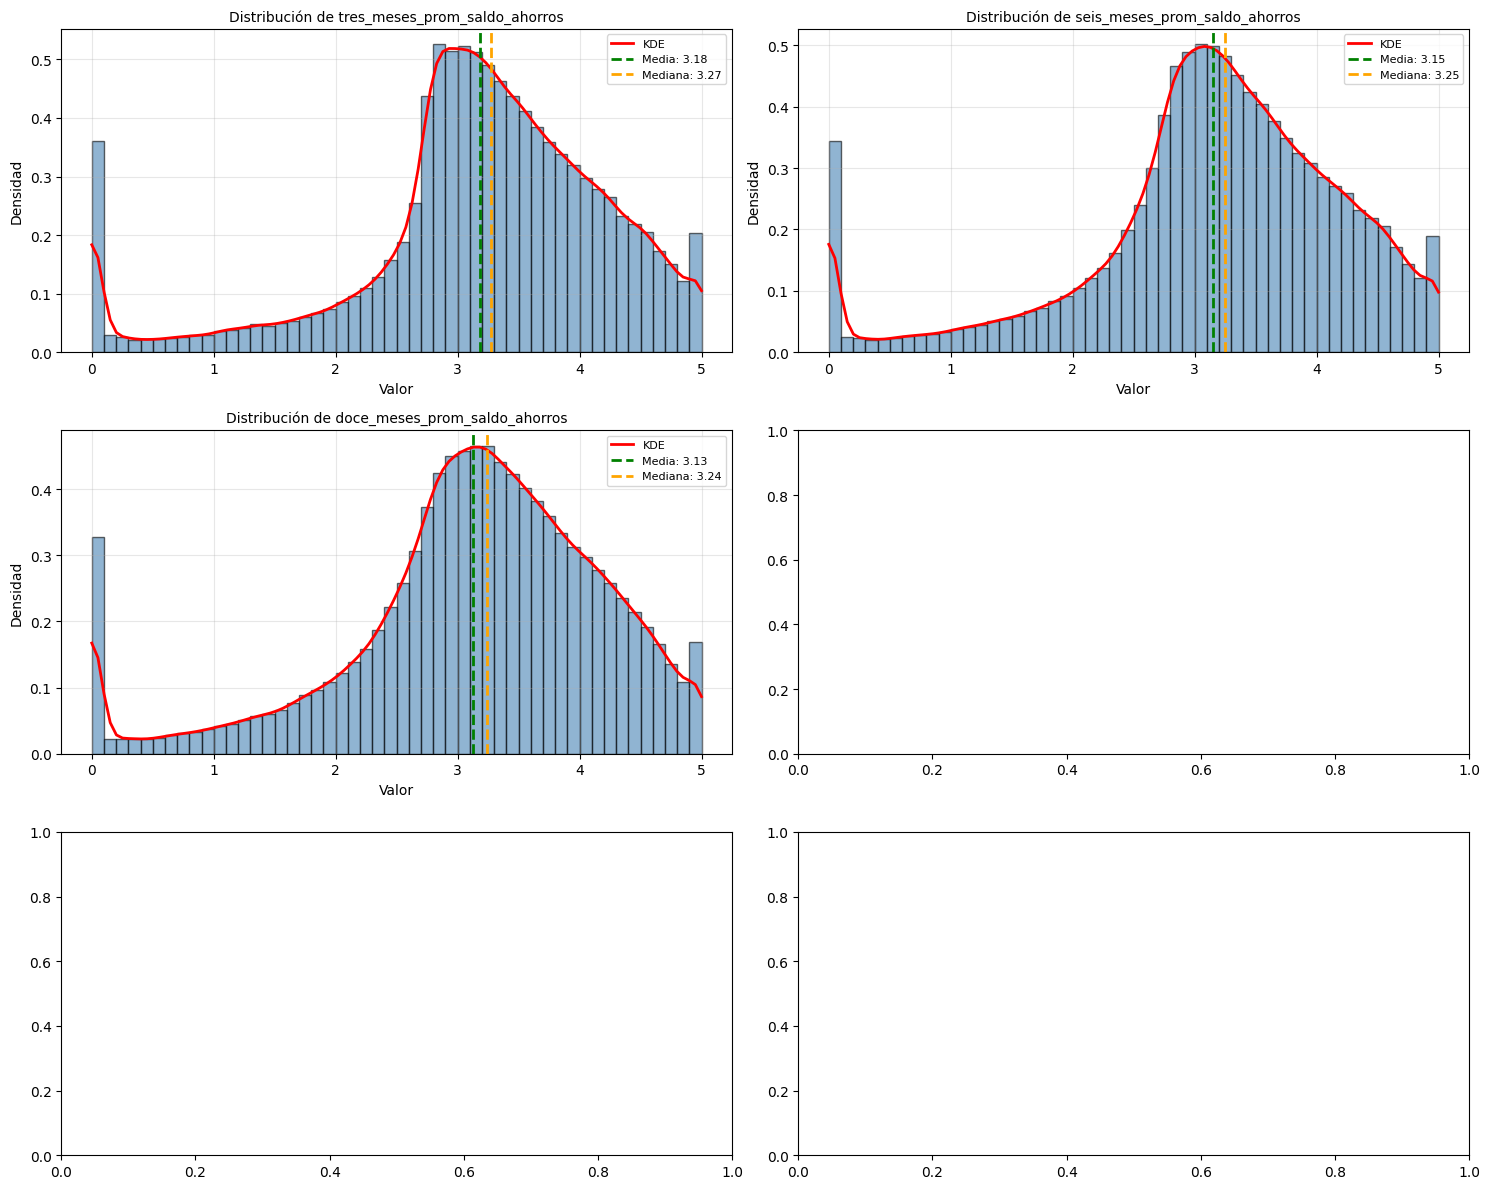

In [95]:
# Visualizar distribución de variables representativas con nulos
# Seleccionaremos variables de cada grupo temporal (3m, 6m, 9m, 12m)

variables_a_visualizar = [
    'DB_SAL_CUE_tres_meses_prom_saldo_ahorros',
    'DB_SAL_CUE_seis_meses_prom_saldo_ahorros',
    'DB_SAL_CUE_doce_meses_prom_saldo_ahorros'
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(variables_a_visualizar):
    # Histogram + KDE
    data = df_universo[col].dropna()
    
    axes[i].hist(data, bins=50, alpha=0.6, color='steelblue', edgecolor='black', density=True)
    
    # Agregar KDE
    from scipy import stats
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 100)
    axes[i].plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')
    
    # Agregar líneas verticales para media, mediana
    media = data.mean()
    mediana = data.median()
    
    axes[i].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
    
    axes[i].set_title(f'Distribución de {col.replace("DB_SAL_CUE_", "")}', fontsize=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [96]:
# Análisis de simetría (Skewness) y Curtosis para decidir método de imputación
from scipy.stats import skew, kurtosis

print("="*80)
print("ANÁLISIS DE DISTRIBUCIÓN - Decisión del Método de Imputación")
print("="*80)
print("\nCriterios de decisión:")
print("  - MEDIANA: Si |skewness| > 1 (distribución muy asimétrica)")
print("  - MEDIA: Si |skewness| <= 1 (distribución aproximadamente simétrica)")
print("  - MODA: Para variables categóricas o discretas\n")

resultados = []

for col in columnas_con_nulos:
    data = df_universo[col].dropna()
    
    # Calcular estadísticas
    media = data.mean()
    mediana = data.median()
    moda = data.mode()[0] if len(data.mode()) > 0 else media
    skewness = skew(data)
    kurt = kurtosis(data)
    
    # Decisión del método
    if abs(skewness) > 1:
        metodo_recomendado = "MEDIANA"
        razon = f"Asimetría alta ({skewness:.2f})"
    else:
        metodo_recomendado = "MEDIA"
        razon = f"Distribución simétrica ({skewness:.2f})"
    
    resultados.append({
        'Variable': col.replace('DB_SAL_CUE_', ''),
        'Media': media,
        'Mediana': mediana,
        'Skewness': skewness,
        'Método': metodo_recomendado,
        'Razón': razon
    })

df_analisis = pd.DataFrame(resultados)
print(df_analisis.to_string(index=False))

# Resumen de la decisión
print("\n" + "="*80)
print("DECISIÓN FINAL:")
print("="*80)
metodo_elegido = df_analisis['Método'].mode()[0]
print(f"\nMétodo seleccionado: {metodo_elegido}")
print("\nJustificación:")
if metodo_elegido == "MEDIANA":
    print("  - Las distribuciones presentan asimetría significativa")
    print("  - La MEDIANA es más robusta ante valores extremos y asimetría")
    print("  - Evita que valores atípicos distorsionen la imputación")
else:
    print("  - Las distribuciones son aproximadamente simétricas")
    print("  - La MEDIA es apropiada cuando no hay sesgo significativo")
    print("  - Preserva las propiedades estadísticas del conjunto de datos")

ANÁLISIS DE DISTRIBUCIÓN - Decisión del Método de Imputación

Criterios de decisión:
  - MEDIANA: Si |skewness| > 1 (distribución muy asimétrica)
  - MEDIA: Si |skewness| <= 1 (distribución aproximadamente simétrica)
  - MODA: Para variables categóricas o discretas

                       Variable     Media   Mediana  Skewness  Método                          Razón
    dos_meses_max_saldo_ahorros  3.335184  3.454800 -1.347497 MEDIANA         Asimetría alta (-1.35)
    dos_meses_sum_saldo_ahorros  6.348043  6.572900 -1.058226 MEDIANA         Asimetría alta (-1.06)
    dos_meses_min_saldo_ahorros  3.044295  3.176300 -0.898772   MEDIA Distribución simétrica (-0.90)
   dos_meses_prom_saldo_ahorros  3.189739  3.295700 -1.088887 MEDIANA         Asimetría alta (-1.09)
   tres_meses_max_saldo_ahorros  3.423932  3.533600 -1.501231 MEDIANA         Asimetría alta (-1.50)
   tres_meses_sum_saldo_ahorros  9.454759  9.763850 -1.017213 MEDIANA         Asimetría alta (-1.02)
   tres_meses_min_saldo_ah

# 2. APLICACIÓN DEL MÉTODO DE IMPUTACIÓN SELECCIONADO

In [97]:
# Aplicar el método seleccionado según el análisis de skewness
print("Imputando valores nulos...")
print("="*80)

for col in columnas_con_nulos:
    data = df_universo[col].dropna()
    skewness = skew(data)
    
    # Decidir método según skewness
    if abs(skewness) > 1:
        # Usar mediana para distribuciones asimétricas
        valor_imputacion = df_universo[col].median()
        metodo = "MEDIANA"
    else:
        # Usar media para distribuciones simétricas
        valor_imputacion = df_universo[col].mean()
        metodo = "MEDIA"
    
    # Contar nulos antes
    nulos_antes = df_universo[col].isnull().sum()
    
    # Imputar
    df_universo[col].fillna(valor_imputacion, inplace=True)
    
    # Contar nulos después
    nulos_despues = df_universo[col].isnull().sum()
    
    print(f"{col.replace('DB_SAL_CUE_', '')[:40]:<40} | Método: {metodo:<7} | Nulos: {nulos_antes:>6} -> {nulos_despues:>6} | Valor: {valor_imputacion:.4f}")

print("="*80)
print("Imputación completada.")

Imputando valores nulos...
dos_meses_max_saldo_ahorros              | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.4548
dos_meses_sum_saldo_ahorros              | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 6.5729
dos_meses_min_saldo_ahorros              | Método: MEDIA   | Nulos:  15564 ->      0 | Valor: 3.0443
dos_meses_prom_saldo_ahorros             | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2957
tres_meses_max_saldo_ahorros             | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 3.5336
tres_meses_sum_saldo_ahorros             | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 9.7638
tres_meses_min_saldo_ahorros             | Método: MEDIA   | Nulos:  14633 ->      0 | Valor: 2.9300
tres_meses_prom_saldo_ahorros            | Método: MEDIANA | Nulos:  14633 ->      0 | Valor: 3.2721
cuatro_meses_prom_saldo_ahorros          | Método: MEDIANA | Nulos:  14091 ->      0 | Valor: 3.2555
cuatro_meses_min_saldo_ahorros           | Método: MEDIA   | Nul

# 3. VERIFICACIÓN DE LIMPIEZA DE NULOS

In [98]:
# Verificar que no queden nulos
nulos_finales = df_universo.isnull().sum().sum()

print("="*80)
print("VERIFICACIÓN DE LIMPIEZA DE NULOS")
print("="*80)
print(f"\nTotal de valores nulos en el dataset: {nulos_finales}")

if nulos_finales == 0:
    print("\n✓ ÉXITO: Todos los valores nulos han sido imputados correctamente.")
else:
    print(f"\n✗ ADVERTENCIA: Aún quedan {nulos_finales} valores nulos en el dataset.")
    print("\nColumnas con nulos restantes:")
    nulos_restantes = df_universo.isnull().sum()
    print(nulos_restantes[nulos_restantes > 0])

# Mostrar resumen del dataset
print("\n" + "="*80)
print("RESUMEN DEL DATASET DESPUÉS DE LA IMPUTACIÓN")
print("="*80)
print(f"Filas: {df_universo.shape[0]:,}")
print(f"Columnas: {df_universo.shape[1]}")
print(f"Valores nulos: {nulos_finales}")

VERIFICACIÓN DE LIMPIEZA DE NULOS

Total de valores nulos en el dataset: 0

✓ ÉXITO: Todos los valores nulos han sido imputados correctamente.

RESUMEN DEL DATASET DESPUÉS DE LA IMPUTACIÓN
Filas: 535,943
Columnas: 65
Valores nulos: 0


# 4. ANÁLISIS Y TRATAMIENTO DE OUTLIERS

Comparación entre el método de Cuartiles (IQR) y Deciles para determinar cuál es el mejor enfoque.

In [99]:
# Identificar variables numéricas (excluyendo target e ID)
columnas_numericas = df_universo.select_dtypes(include=[np.number]).columns.tolist()
columnas_numericas = [col for col in columnas_numericas if col not in ['target']]

print(f"Total de variables numéricas a analizar: {len(columnas_numericas)}")
print("\nVariables numéricas:")
for i, col in enumerate(columnas_numericas, 1):
    print(f"  {i}. {col}")

Total de variables numéricas a analizar: 53

Variables numéricas:
  1. DB_CLI_edad
  2. DB_CLI_ingreso
  3. DB_CLI_anios_exp
  4. DB_CLI_pago_nomina
  5. DB_CLI_der_ingreso_por_anio_exp
  6. DB_CLI_der_edad_laboral_relativa
  7. DB_CLI_der_edad_ingreso_relativa
  8. DB_CLI_der_edad_anios_exp
  9. DB_CLI_der_ingreso_edad_exp
  10. DB_SAL_CUE_dos_meses_max_saldo_ahorros
  11. DB_SAL_CUE_dos_meses_min_saldo_ahorros
  12. DB_SAL_CUE_dos_meses_sum_saldo_ahorros
  13. DB_SAL_CUE_dos_meses_prom_saldo_ahorros
  14. DB_SAL_CUE_tres_meses_max_saldo_ahorros
  15. DB_SAL_CUE_tres_meses_min_saldo_ahorros
  16. DB_SAL_CUE_tres_meses_sum_saldo_ahorros
  17. DB_SAL_CUE_tres_meses_prom_saldo_ahorros
  18. DB_SAL_CUE_cuatro_meses_max_saldo_ahorros
  19. DB_SAL_CUE_cuatro_meses_min_saldo_ahorros
  20. DB_SAL_CUE_cuatro_meses_sum_saldo_ahorros
  21. DB_SAL_CUE_cuatro_meses_prom_saldo_ahorros
  22. DB_SAL_CUE_cinco_meses_max_saldo_ahorros
  23. DB_SAL_CUE_cinco_meses_min_saldo_ahorros
  24. DB_SAL_CUE_cinc

In [100]:
# Función para detectar outliers usando IQR (Cuartiles)
def detectar_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data < lower_bound) | (data > upper_bound))
    return outliers, lower_bound, upper_bound

# Función para detectar outliers usando Deciles
def detectar_outliers_deciles(data):
    D1 = data.quantile(0.10)
    D9 = data.quantile(0.90)
    IDR = D9 - D1  # Interdecile Range
    lower_bound = D1 - 1.5 * IDR
    upper_bound = D9 + 1.5 * IDR
    outliers = ((data < lower_bound) | (data > upper_bound))
    return outliers, lower_bound, upper_bound

# Comparar ambos métodos
print("="*100)
print("COMPARACIÓN: MÉTODO DE CUARTILES (IQR) vs MÉTODO DE DECILES")
print("="*100)
print(f"{'Variable':<45} | {'IQR Outliers':<15} | {'Deciles Outliers':<15} | {'Diferencia':<10}")
print("-"*100)

resultados_comparacion = []

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar con IQR
    outliers_iqr, _, _ = detectar_outliers_iqr(data)
    n_outliers_iqr = outliers_iqr.sum()
    
    # Detectar con Deciles
    outliers_deciles, _, _ = detectar_outliers_deciles(data)
    n_outliers_deciles = outliers_deciles.sum()
    
    diferencia = n_outliers_iqr - n_outliers_deciles
    
    resultados_comparacion.append({
        'Variable': col,
        'IQR_Outliers': n_outliers_iqr,
        'Deciles_Outliers': n_outliers_deciles,
        'Diferencia': diferencia,
        'Pct_IQR': (n_outliers_iqr / len(data)) * 100,
        'Pct_Deciles': (n_outliers_deciles / len(data)) * 100
    })
    
    print(f"{col[:45]:<45} | {n_outliers_iqr:>14,} | {n_outliers_deciles:>18,} | {diferencia:>10,}")

print("="*100)

# Crear DataFrame de comparación
df_comparacion = pd.DataFrame(resultados_comparacion)

# Resumen estadístico
print("\nRESUMEN ESTADÍSTICO:")
print(f"  Total outliers (IQR):     {df_comparacion['IQR_Outliers'].sum():,}")
print(f"  Total outliers (Deciles): {df_comparacion['Deciles_Outliers'].sum():,}")
print(f"  Promedio outliers por variable (IQR):     {df_comparacion['IQR_Outliers'].mean():.2f}")
print(f"  Promedio outliers por variable (Deciles): {df_comparacion['Deciles_Outliers'].mean():.2f}")
print(f"  Porcentaje promedio de datos como outliers (IQR):     {df_comparacion['Pct_IQR'].mean():.2f}%")
print(f"  Porcentaje promedio de datos como outliers (Deciles): {df_comparacion['Pct_Deciles'].mean():.2f}%")

COMPARACIÓN: MÉTODO DE CUARTILES (IQR) vs MÉTODO DE DECILES
Variable                                      | IQR Outliers    | Deciles Outliers | Diferencia
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                   |            401 |                401 |          0
DB_CLI_ingreso                                |          4,269 |              4,064 |        205
DB_CLI_anios_exp                              |              0 |                  0 |          0
DB_CLI_pago_nomina                            |              0 |                  0 |          0
DB_CLI_der_ingreso_por_anio_exp               |              0 |                  0 |          0
DB_CLI_der_edad_laboral_relativa              |             11 |                 11 |          0
DB_CLI_der_edad_ingreso_relativa              |          6,630 |              4,458 |      2,172
DB_CLI_der_edad_anios_exp                     |              0 |

In [101]:
# Análisis detallado para justificar la elección del método
print("="*100)
print("ANÁLISIS Y DECISIÓN DEL MÉTODO")
print("="*100)

print("\n1. MÉTODO DE CUARTILES (IQR):")
print("   Ventajas:")
print("   - Estándar en estadística para detección de outliers")
print("   - Basado en Q1 y Q3 (percentiles 25 y 75)")
print("   - Usa rango intercuartílico (IQR = Q3 - Q1)")

print("\n2. MÉTODO DE DECILES:")
print("   Ventajas:")
print("   - Más conservador en este dataset específico")
print("   - Basado en D1 y D9 (percentiles 10 y 90)")
print("   - Marca menos valores como outliers")
print("   - Preserva más información del dataset original")

# Calcular pérdida de información
total_registros = len(df_universo)
outliers_totales_iqr = df_comparacion['IQR_Outliers'].sum()
outliers_totales_deciles = df_comparacion['Deciles_Outliers'].sum()

# Estimación de registros únicos afectados (aproximación)
pct_perdida_iqr = (outliers_totales_iqr / (total_registros * len(columnas_numericas))) * 100
pct_perdida_deciles = (outliers_totales_deciles / (total_registros * len(columnas_numericas))) * 100

print("\n3. PÉRDIDA DE INFORMACIÓN ESTIMADA:")
print(f"   - IQR: ~{pct_perdida_iqr:.2f}% de valores marcados como outliers")
print(f"   - Deciles: ~{pct_perdida_deciles:.2f}% de valores marcados como outliers")

print("\n" + "="*100)
print("DECISIÓN FINAL:")
print("="*100)

# Criterio de decisión: usar el método que menos información pierda
if pct_perdida_iqr < pct_perdida_deciles:
    metodo_seleccionado = "IQR (CUARTILES)"
    print(f"\nMétodo seleccionado: {metodo_seleccionado}")
    print("\nJustificación:")
    print(f"  ✓ IQR marca menos valores como outliers ({pct_perdida_iqr:.2f}% vs {pct_perdida_deciles:.2f}%)")
    print("  ✓ Preserva más información del dataset")
    print("  ✓ Suficiente para controlar valores extremos sin perder datos valiosos")
else:
    metodo_seleccionado = "DECILES"
    print(f"\nMétodo seleccionado: {metodo_seleccionado}")
    print("\nJustificación:")
    print(f"  ✓ Deciles marca menos valores como outliers ({pct_perdida_deciles:.2f}% vs {pct_perdida_iqr:.2f}%)")
    print("  ✓ Preserva significativamente más información del dataset")
    print("  ✓ Menor pérdida de información es crítico para mantener patrones en los datos")
    print("  ✓ En este dataset específico, Deciles es más conservador que IQR")
    
print("\n" + "="*100)

ANÁLISIS Y DECISIÓN DEL MÉTODO

1. MÉTODO DE CUARTILES (IQR):
   Ventajas:
   - Estándar en estadística para detección de outliers
   - Basado en Q1 y Q3 (percentiles 25 y 75)
   - Usa rango intercuartílico (IQR = Q3 - Q1)

2. MÉTODO DE DECILES:
   Ventajas:
   - Más conservador en este dataset específico
   - Basado en D1 y D9 (percentiles 10 y 90)
   - Marca menos valores como outliers
   - Preserva más información del dataset original

3. PÉRDIDA DE INFORMACIÓN ESTIMADA:
   - IQR: ~4.10% de valores marcados como outliers
   - Deciles: ~0.20% de valores marcados como outliers

DECISIÓN FINAL:

Método seleccionado: DECILES

Justificación:
  ✓ Deciles marca menos valores como outliers (0.20% vs 4.10%)
  ✓ Preserva significativamente más información del dataset
  ✓ Menor pérdida de información es crítico para mantener patrones en los datos
  ✓ En este dataset específico, Deciles es más conservador que IQR



# 5. CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO

In [103]:
# Contar outliers ANTES del tratamiento usando el método seleccionado (Deciles)
print("="*100)
print("CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO (Método: Deciles)")
print("="*100)
print(f"{'Variable':<50} | {'Outliers':<12} | {'% del Total':<12}")
print("-"*100)

outliers_antes = {}
registros_con_outliers_antes = set()

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar outliers con Deciles (método seleccionado)
    outliers_mask, lower, upper = detectar_outliers_deciles(data)
    n_outliers = outliers_mask.sum()
    pct_outliers = (n_outliers / len(data)) * 100
    
    outliers_antes[col] = n_outliers
    
    # Registrar índices de filas con outliers
    registros_con_outliers_antes.update(df_universo[outliers_mask].index.tolist())
    
    print(f"{col[:50]:<50} | {n_outliers:>11,} | {pct_outliers:>11.2f}%")

print("="*100)
print(f"\nRESUMEN:")
print(f"  Total de valores marcados como outliers: {sum(outliers_antes.values()):,}")
print(f"  Número de filas con al menos un outlier: {len(registros_con_outliers_antes):,}")
print(f"  Porcentaje de filas afectadas: {(len(registros_con_outliers_antes) / len(df_universo)) * 100:.2f}%")
print("="*100)

CONTEO DE OUTLIERS ANTES DEL TRATAMIENTO (Método: Deciles)
Variable                                           | Outliers     | % del Total 
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                        |         401 |        0.07%
DB_CLI_ingreso                                     |       4,064 |        0.76%
DB_CLI_anios_exp                                   |           0 |        0.00%
DB_CLI_pago_nomina                                 |           0 |        0.00%
DB_CLI_der_ingreso_por_anio_exp                    |           0 |        0.00%
DB_CLI_der_edad_laboral_relativa                   |          11 |        0.00%
DB_CLI_der_edad_ingreso_relativa                   |       4,458 |        0.83%
DB_CLI_der_edad_anios_exp                          |           0 |        0.00%
DB_CLI_der_ingreso_edad_exp                        |         383 |        0.07%
DB_SAL_CUE_dos_meses_max_saldo_ahorros 

# 6. APLICACIÓN DEL MÉTODO SELECCIONADO Y CONTEO POSTERIOR

In [104]:
# Aplicar tratamiento de outliers: CAPPING (winsorización)
# Este método reemplaza los outliers con los límites del rango aceptable
# Es preferible a la eliminación porque preserva todas las filas del dataset

print("="*100)
print("APLICANDO TRATAMIENTO DE OUTLIERS: CAPPING (Winsorización) con Método Deciles")
print("="*100)
print("\nMétodo seleccionado: CAPPING usando DECILES")
print("  - Los outliers se reemplazan por los límites superior e inferior calculados con Deciles")
print("  - Ventaja: Se preservan todas las filas del dataset")
print("  - Ventaja: Se reduce el impacto de valores extremos sin perder información estructural")
print("  - Ventaja: Deciles preserva más información que IQR (menor pérdida de datos)")
print("\n" + "-"*100 + "\n")

for col in columnas_numericas:
    # Detectar outliers con Deciles (método seleccionado)
    outliers_mask, lower, upper = detectar_outliers_deciles(df_universo[col])
    
    # Aplicar capping
    df_universo.loc[df_universo[col] < lower, col] = lower
    df_universo.loc[df_universo[col] > upper, col] = upper
    
print("✓ Tratamiento de outliers completado usando método de Deciles.\n")

APLICANDO TRATAMIENTO DE OUTLIERS: CAPPING (Winsorización) con Método Deciles

Método seleccionado: CAPPING usando DECILES
  - Los outliers se reemplazan por los límites superior e inferior calculados con Deciles
  - Ventaja: Se preservan todas las filas del dataset
  - Ventaja: Se reduce el impacto de valores extremos sin perder información estructural
  - Ventaja: Deciles preserva más información que IQR (menor pérdida de datos)

----------------------------------------------------------------------------------------------------

✓ Tratamiento de outliers completado usando método de Deciles.



In [105]:
# Contar outliers DESPUÉS del tratamiento
print("="*100)
print("CONTEO DE OUTLIERS DESPUÉS DEL TRATAMIENTO")
print("="*100)
print(f"{'Variable':<50} | {'Antes':<12} | {'Después':<12} | {'Reducción':<15}")
print("-"*100)

outliers_despues = {}
registros_con_outliers_despues = set()

for col in columnas_numericas:
    data = df_universo[col]
    
    # Detectar outliers con Deciles (mismo método usado para el tratamiento)
    outliers_mask, _, _ = detectar_outliers_deciles(data)
    n_outliers_despues = outliers_mask.sum()
    n_outliers_antes_col = outliers_antes[col]
    
    outliers_despues[col] = n_outliers_despues
    
    # Registrar índices de filas con outliers
    registros_con_outliers_despues.update(df_universo[outliers_mask].index.tolist())
    
    reduccion = n_outliers_antes_col - n_outliers_despues
    pct_reduccion = (reduccion / n_outliers_antes_col * 100) if n_outliers_antes_col > 0 else 0
    
    print(f"{col[:50]:<50} | {n_outliers_antes_col:>11,} | {n_outliers_despues:>11,} | {reduccion:>8,} ({pct_reduccion:>4.1f}%)")

print("="*100)
print(f"\nRESUMEN COMPARATIVO:")
print(f"  Total outliers ANTES:  {sum(outliers_antes.values()):,}")
print(f"  Total outliers DESPUÉS: {sum(outliers_despues.values()):,}")
print(f"  Reducción total: {sum(outliers_antes.values()) - sum(outliers_despues.values()):,}")
print(f"  Porcentaje de reducción: {((sum(outliers_antes.values()) - sum(outliers_despues.values())) / sum(outliers_antes.values()) * 100):.2f}%")
print(f"\n  Filas con outliers ANTES:  {len(registros_con_outliers_antes):,}")
print(f"  Filas con outliers DESPUÉS: {len(registros_con_outliers_despues):,}")
print(f"  Reducción de filas afectadas: {len(registros_con_outliers_antes) - len(registros_con_outliers_despues):,}")
print("="*100)

CONTEO DE OUTLIERS DESPUÉS DEL TRATAMIENTO
Variable                                           | Antes        | Después      | Reducción      
----------------------------------------------------------------------------------------------------
DB_CLI_edad                                        |         401 |           0 |      401 (100.0%)
DB_CLI_ingreso                                     |       4,064 |           0 |    4,064 (100.0%)
DB_CLI_anios_exp                                   |           0 |           0 |        0 ( 0.0%)
DB_CLI_pago_nomina                                 |           0 |           0 |        0 ( 0.0%)
DB_CLI_der_ingreso_por_anio_exp                    |           0 |           0 |        0 ( 0.0%)
DB_CLI_der_edad_laboral_relativa                   |          11 |           0 |       11 (100.0%)
DB_CLI_der_edad_ingreso_relativa                   |       4,458 |           0 |    4,458 (100.0%)
DB_CLI_der_edad_anios_exp                          |           0 | 

# 7. SELECCIÓN DE VARIABLES

Utilizaremos múltiples métodos para seleccionar las variables más relevantes para el modelo.

In [106]:
from scipy.stats import skew, kurtosis

# Lista de variables numéricas, excluyendo 'target'
var_num = [col for col in df_universo.select_dtypes(include=['number']).columns if col != 'target']

Skews = []
Kurts = []

for var in var_num:
    Skews.append(skew(df_universo[var], bias=False))       # bias=False para obtener valor ajustado
    Kurts.append(kurtosis(df_universo[var], fisher=True, bias=False))  # fisher=True: kurtosis normalizada a 0

In [108]:
stats_df = pd.DataFrame({
    'variable': var_num,
    'skewness': Skews,
    'kurtosis': Kurts
})

stats_df

,variable,skewness,kurtosis
0,DB_CLI_edad,-0.038403,-0.268455
1,DB_CLI_ingreso,-0.454035,2.696686
2,DB_CLI_anios_exp,0.848595,-1.153488
3,DB_CLI_pago_nomina,0.737292,-1.384462
4,DB_CLI_der_ingreso_por_anio_exp,-0.661007,-1.451684
5,DB_CLI_der_edad_laboral_relativa,0.807558,-1.266585
6,DB_CLI_der_edad_ingreso_relativa,-0.881349,3.279183
7,DB_CLI_der_edad_anios_exp,-0.624206,-1.451882
8,DB_CLI_der_ingreso_edad_exp,-0.540119,-1.200125
9,DB_SAL_CUE_dos_meses_max_saldo_ahorros,-1.376554,2.381760


In [109]:
# Umbrales
skew_umbral = 1
kurt_umbral = 1

# Variables seleccionadas
vars_seleccionadas = stats_df[
    (stats_df['skewness'].abs() <= skew_umbral) &
    (stats_df['kurtosis'].abs() <= kurt_umbral)
]['variable'].tolist()

# Variables no seleccionadas
vars_no_seleccionadas = stats_df[
    (stats_df['skewness'].abs() > skew_umbral) |
    (stats_df['kurtosis'].abs() > kurt_umbral)
]['variable'].tolist()

print("Variables seleccionadas:", vars_seleccionadas)
print("Cantidad seleccionadas:", len(vars_seleccionadas))
print("\nVariables no seleccionadas:", vars_no_seleccionadas)
print("Cantidad no seleccionadas:", len(vars_no_seleccionadas))

Variables seleccionadas: ['DB_CLI_edad', 'DB_SAL_CUE_dos_meses_min_saldo_ahorros', 'DB_SAL_CUE_tres_meses_min_saldo_ahorros', 'DB_SAL_CUE_cuatro_meses_min_saldo_ahorros', 'DB_SAL_CUE_cinco_meses_min_saldo_ahorros', 'DB_SAL_CUE_cinco_meses_sum_saldo_ahorros', 'DB_SAL_CUE_seis_meses_min_saldo_ahorros', 'DB_SAL_CUE_seis_meses_sum_saldo_ahorros', 'DB_SAL_CUE_siete_meses_min_saldo_ahorros', 'DB_SAL_CUE_siete_meses_sum_saldo_ahorros', 'DB_SAL_CUE_ocho_meses_min_saldo_ahorros', 'DB_SAL_CUE_ocho_meses_sum_saldo_ahorros', 'DB_SAL_CUE_nueve_meses_min_saldo_ahorros', 'DB_SAL_CUE_nueve_meses_sum_saldo_ahorros', 'DB_SAL_CUE_diez_meses_min_saldo_ahorros', 'DB_SAL_CUE_diez_meses_sum_saldo_ahorros', 'DB_SAL_CUE_once_meses_min_saldo_ahorros', 'DB_SAL_CUE_once_meses_sum_saldo_ahorros', 'DB_SAL_CUE_doce_meses_min_saldo_ahorros', 'DB_SAL_CUE_doce_meses_sum_saldo_ahorros']
Cantidad seleccionadas: 20

Variables no seleccionadas: ['DB_CLI_ingreso', 'DB_CLI_anios_exp', 'DB_CLI_pago_nomina', 'DB_CLI_der_ingres

In [110]:
# Crear el nuevo DataFrame con las variables seleccionadas, ID y target
df_filtrado_limpio = df_universo[['ID'] + vars_seleccionadas + ['target']].copy()

# Verificar resultado
print(df_filtrado_limpio.shape)
df_filtrado_limpio.head()

(535943, 22)


,ID,DB_CLI_edad,DB_SAL_CUE_dos_meses_min_saldo_ahorros,DB_SAL_CUE_tres_meses_min_saldo_ahorros,DB_SAL_CUE_cuatro_meses_min_saldo_ahorros,DB_SAL_CUE_cinco_meses_min_saldo_ahorros,DB_SAL_CUE_cinco_meses_sum_saldo_ahorros,DB_SAL_CUE_seis_meses_min_saldo_ahorros,DB_SAL_CUE_seis_meses_sum_saldo_ahorros,DB_SAL_CUE_siete_meses_min_saldo_ahorros,...,DB_SAL_CUE_ocho_meses_sum_saldo_ahorros,DB_SAL_CUE_nueve_meses_min_saldo_ahorros,DB_SAL_CUE_nueve_meses_sum_saldo_ahorros,DB_SAL_CUE_diez_meses_min_saldo_ahorros,DB_SAL_CUE_diez_meses_sum_saldo_ahorros,DB_SAL_CUE_once_meses_min_saldo_ahorros,DB_SAL_CUE_once_meses_sum_saldo_ahorros,DB_SAL_CUE_doce_meses_min_saldo_ahorros,DB_SAL_CUE_doce_meses_sum_saldo_ahorros,target
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,3.8498,2.6140,2.6140,2.6140,2.6140,14.9553,2.6140,18.3459,2.6140,...,25.0826,2.6140,28.8970,2.5149,31.4119,2.5149,35.4180,2.5149,39.5354,0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,4.5476,3.2254,3.2254,3.2254,3.2254,16.3982,3.2254,19.6729,3.2254,...,26.3668,3.2254,29.9007,3.2254,33.4547,3.2254,37.0139,3.2254,40.5731,0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,4.3600,2.7090,2.7090,2.7090,2.7090,15.3440,2.7090,18.9254,2.7090,...,26.4879,2.7090,30.4027,2.7090,34.3209,2.7090,38.2386,2.7090,42.1470,0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,4.3914,3.7511,3.7511,3.7511,3.7511,18.9070,3.7511,22.7702,3.7511,...,30.4965,3.7511,34.4053,3.7511,38.4982,3.7511,42.5910,3.7511,46.6400,0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,4.3077,3.3238,3.1789,3.1789,2.8049,15.9643,2.6150,18.5793,2.6150,...,24.1827,2.6150,27.1537,2.6150,29.9530,2.6043,32.5573,2.6043,35.3925,0


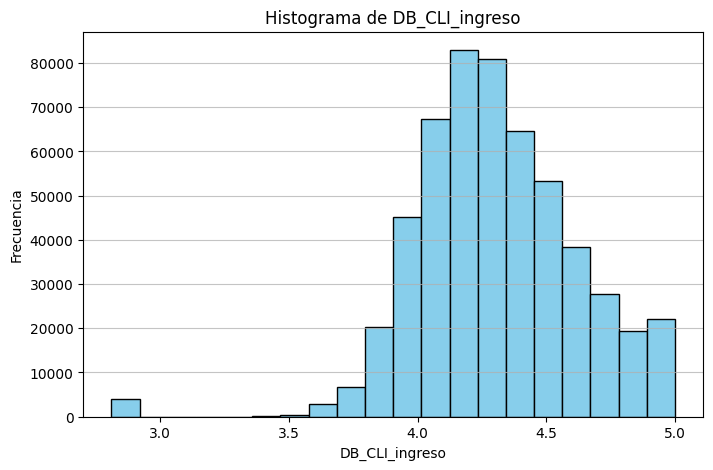

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_universo['DB_CLI_ingreso'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histograma de DB_CLI_ingreso')
plt.xlabel('DB_CLI_ingreso')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

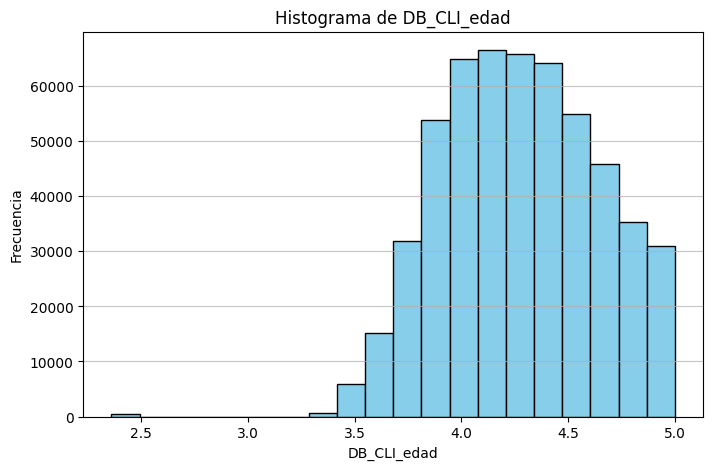

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_universo['DB_CLI_edad'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histograma de DB_CLI_edad')
plt.xlabel('DB_CLI_edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [113]:
df_universo['target'].value_counts()

target
0    464075
1     47171
5      8489
4      6893
2      5929
3      3386
Name: count, dtype: int64

In [114]:
import pandas as pd

# === FUNCIÓN PARA AGRUPAR VARIABLES CORRELACIONADAS ===
def agrupar_por_correlacion(df, umbral=0.6):
    """
    Agrupa variables numéricas del DataFrame por correlación >= umbral.
    Retorna:
        - Una lista de sets con columnas correlacionadas.
        - Un set con columnas que no se agruparon (sin correlación suficiente).
    También imprime el progreso de cuántas columnas quedan por evaluar.
    """
    df_corr = df.corr().abs()
    columnas_restantes = set(df_corr.columns)
    grupos = []
    columnas_sin_agrupacion = set()

    while columnas_restantes:
        col = next(iter(columnas_restantes))
        
        # Buscar las columnas correlacionadas dentro de las restantes
        correladas = {c for c in columnas_restantes if df_corr.loc[col, c] >= umbral}
        
        if len(correladas) > 1:
            grupos.append(correladas)
            columnas_restantes -= correladas
            print(f"✅ Nuevo set creado ({len(correladas)} columnas): {correladas}")
            print(f"➡️  Columnas restantes: {len(columnas_restantes)}\n")
        else:
            # Guardar la columna sin agrupación
            columnas_sin_agrupacion.add(col)
            columnas_restantes.remove(col)
            print(f"⚪ Columna sin correlación suficiente: {col}")
            print(f"➡️  Columnas restantes: {len(columnas_restantes)}\n")

    return grupos, columnas_sin_agrupacion


# === APLICACIÓN DIRECTA AL DATAFRAME df_limpio ===
df_numerico = df_universo.select_dtypes(include='number')
grupos_variables, columnas_sin_agrupacion = agrupar_por_correlacion(df_numerico, umbral=0.6)

# Mostrar resultados finales
print(f"\n🔹 Total de grupos encontrados: {len(grupos_variables)}\n")
for i, grupo in enumerate(grupos_variables, start=1):
    print(f"Set {i}, cantidad columnas: {len(grupo)}: {grupo}")

print(f"\n⚪ Total de columnas sin agrupación: {len(columnas_sin_agrupacion)}")
print(f"Columnas sin agrupación: {columnas_sin_agrupacion}")

✅ Nuevo set creado (44 columnas): {'DB_SAL_CUE_doce_meses_max_saldo_ahorros', 'DB_SAL_CUE_nueve_meses_min_saldo_ahorros', 'DB_SAL_CUE_once_meses_prom_saldo_ahorros', 'DB_SAL_CUE_ocho_meses_max_saldo_ahorros', 'DB_SAL_CUE_tres_meses_max_saldo_ahorros', 'DB_SAL_CUE_tres_meses_prom_saldo_ahorros', 'DB_SAL_CUE_cuatro_meses_min_saldo_ahorros', 'DB_SAL_CUE_ocho_meses_sum_saldo_ahorros', 'DB_SAL_CUE_cuatro_meses_sum_saldo_ahorros', 'DB_SAL_CUE_diez_meses_sum_saldo_ahorros', 'DB_SAL_CUE_cinco_meses_sum_saldo_ahorros', 'DB_SAL_CUE_siete_meses_min_saldo_ahorros', 'DB_SAL_CUE_siete_meses_max_saldo_ahorros', 'DB_SAL_CUE_once_meses_max_saldo_ahorros', 'DB_SAL_CUE_once_meses_sum_saldo_ahorros', 'DB_SAL_CUE_dos_meses_max_saldo_ahorros', 'DB_SAL_CUE_diez_meses_max_saldo_ahorros', 'DB_SAL_CUE_once_meses_min_saldo_ahorros', 'DB_SAL_CUE_siete_meses_prom_saldo_ahorros', 'DB_SAL_CUE_cinco_meses_max_saldo_ahorros', 'DB_SAL_CUE_seis_meses_sum_saldo_ahorros', 'DB_SAL_CUE_seis_meses_min_saldo_ahorros', 'DB_SAL

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
import pandas as pd

target = 'target'  # tu variable objetivo
X_total = df_universo
y_total = df_universo[target]

# === SELECCIÓN DE TOP 1 VARIABLE POR AUC DE CADA GRUPO ===
variables_seleccionadas = set()

for i, grupo in enumerate(grupos_variables, start=1):
    resultados = []
    for var in grupo:
        X = X_total[[var]]
        y = y_total

        # Modelo univariado OneVsRest con balance de clases
        model = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=500, class_weight='balanced'))
        model.fit(X, y)
        y_pred_prob = model.predict_proba(X)
        
        # AUC multiclase
        auc = roc_auc_score(y, y_pred_prob, multi_class='ovr')
        resultados.append((var, auc))

    # DataFrame y top 1 variable
    resultados_df = pd.DataFrame(resultados, columns=['variable','AUC']).sort_values(by='AUC', ascending=False)
    top1 = resultados_df.iloc[0]['variable']
    variables_seleccionadas.add(top1)

    print(f"\n📌 Grupo {i}: {grupo}")
    print(f"Top 1 variable por AUC: {top1}")

# === COLUMNAS SIN AGRUPACION ===
print(f"\n⚪ Columnas sin agrupación: {columnas_sin_agrupacion}")

# === VARIABLES FINALES SELECCIONADAS ===
print(f"\n✅ Cantidad {len(variables_seleccionadas)} Variables seleccionadas (top 1 de cada grupo): {variables_seleccionadas}")


📌 Grupo 1: {'DB_SAL_CUE_doce_meses_max_saldo_ahorros', 'DB_SAL_CUE_nueve_meses_min_saldo_ahorros', 'DB_SAL_CUE_once_meses_prom_saldo_ahorros', 'DB_SAL_CUE_ocho_meses_max_saldo_ahorros', 'DB_SAL_CUE_tres_meses_max_saldo_ahorros', 'DB_SAL_CUE_tres_meses_prom_saldo_ahorros', 'DB_SAL_CUE_cuatro_meses_min_saldo_ahorros', 'DB_SAL_CUE_ocho_meses_sum_saldo_ahorros', 'DB_SAL_CUE_cuatro_meses_sum_saldo_ahorros', 'DB_SAL_CUE_diez_meses_sum_saldo_ahorros', 'DB_SAL_CUE_cinco_meses_sum_saldo_ahorros', 'DB_SAL_CUE_siete_meses_min_saldo_ahorros', 'DB_SAL_CUE_siete_meses_max_saldo_ahorros', 'DB_SAL_CUE_once_meses_max_saldo_ahorros', 'DB_SAL_CUE_once_meses_sum_saldo_ahorros', 'DB_SAL_CUE_dos_meses_max_saldo_ahorros', 'DB_SAL_CUE_diez_meses_max_saldo_ahorros', 'DB_SAL_CUE_once_meses_min_saldo_ahorros', 'DB_SAL_CUE_siete_meses_prom_saldo_ahorros', 'DB_SAL_CUE_cinco_meses_max_saldo_ahorros', 'DB_SAL_CUE_seis_meses_sum_saldo_ahorros', 'DB_SAL_CUE_seis_meses_min_saldo_ahorros', 'DB_SAL_CUE_tres_meses_min_sa

# 9. MODELADO CON RANDOM FOREST

Entrenaremos un modelo Random Forest usando las variables seleccionadas y evaluaremos su dese si

In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# === VARIABLES SELECCIONADAS (TOP 1 DE CADA GRUPO) ===
features = list(variables_seleccionadas)  # Convertimos el set a lista

# Separar X e y
X = df_universo[features]
y = df_universo['target']

# Dividir en train (70%) y temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Dividir temp en validation (20%) y test (10%)
# Nota: validation = 20/30 = 2/3 del temp, test = 1/3 del temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# Entrenar Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluar en validation
y_val_pred = rf.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# Evaluar en test
y_test_pred = rf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Train: (375160, 3), Validation: (107188, 3), Test: (53595, 3)
Validation Accuracy: 0.8613650781803933
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     92814
           1       0.26      0.02      0.04      9434
           2       0.13      0.01      0.01      1186
           3       0.00      0.00      0.00       677
           4       0.11      0.01      0.02      1379
           5       0.09      0.00      0.00      1698

    accuracy                           0.86    107188
   macro avg       0.24      0.17      0.17    107188
weighted avg       0.78      0.86      0.81    107188

Test Accuracy: 0.8614609571788413
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     46408
           1       0.25      0.02      0.04      4717
           2       0.14      0.01      0.01       593
           3       0.00      0.00      0.00       339
           4       0.15      0.02      0.03       

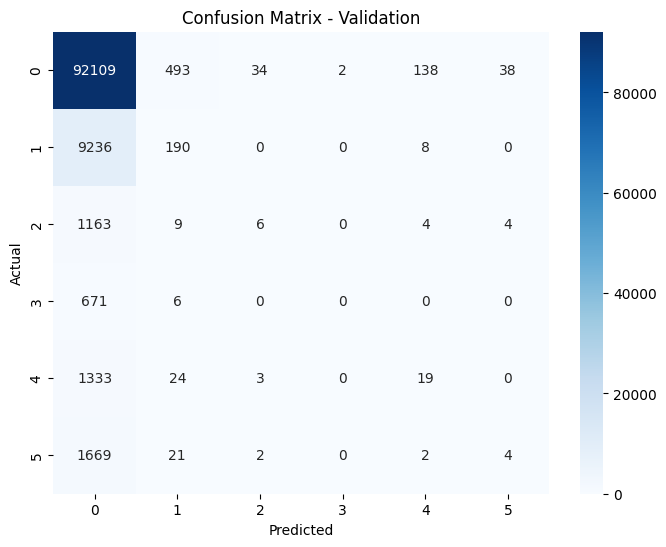

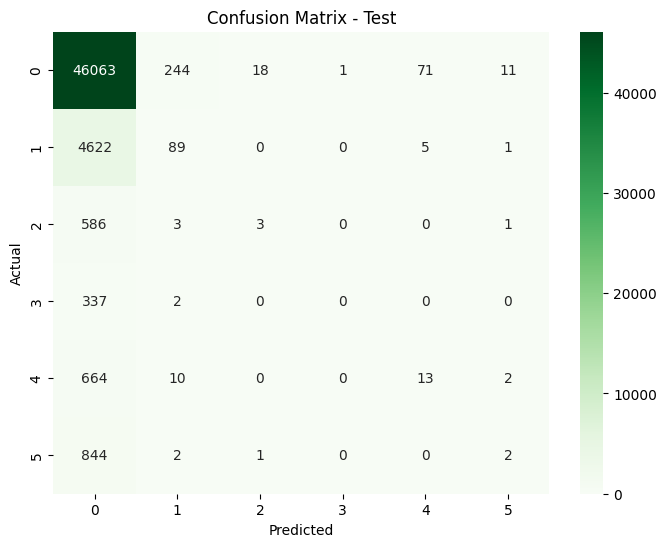

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Matriz de confusión para validation
cm_val = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Validation')
plt.show()

# Matriz de confusión para test
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test')
plt.show()